## Task-D: Collinear features and their effect on linear models

In [94]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

In [95]:
data = pd.read_csv('task_d.csv')

In [96]:
data.head()

,x,y,z,x*x,2*y,2*z+3*x*x,w,target
0,-0.581066,0.841837,-1.012978,-0.604025,0.841837,-0.665927,-0.536277,0
1,-0.894309,-0.207835,-1.012978,-0.883052,-0.207835,-0.917054,-0.522364,0
2,-1.207552,0.212034,-1.082312,-1.150918,0.212034,-1.166507,0.205738,0
3,-1.364174,0.002099,-0.943643,-1.280666,0.002099,-1.266540,-0.665720,0
4,-0.737687,1.051772,-1.012978,-0.744934,1.051772,-0.792746,-0.735054,0


In [97]:
X = data.drop(['target'], axis=1).values
Y = data['target'].values

In [98]:
print(data.corr())

                  x         y         z       x*x       2*y  2*z+3*x*x  \
x          1.000000 -0.205926  0.812458  0.997947 -0.205926   0.996252   
y         -0.205926  1.000000 -0.602663 -0.209289  1.000000  -0.261123   
z          0.812458 -0.602663  1.000000  0.807137 -0.602663   0.847163   
x*x        0.997947 -0.209289  0.807137  1.000000 -0.209289   0.997457   
2*y       -0.205926  1.000000 -0.602663 -0.209289  1.000000  -0.261123   
2*z+3*x*x  0.996252 -0.261123  0.847163  0.997457 -0.261123   1.000000   
w          0.583277 -0.401790  0.674486  0.583803 -0.401790   0.606860   
target     0.728290 -0.690684  0.969990  0.719570 -0.690684   0.764729   

                  w    target  
x          0.583277  0.728290  
y         -0.401790 -0.690684  
z          0.674486  0.969990  
x*x        0.583803  0.719570  
2*y       -0.401790 -0.690684  
2*z+3*x*x  0.606860  0.764729  
w          1.000000  0.641750  
target     0.641750  1.000000  


# Ploting heat map of the correlation among the feature 

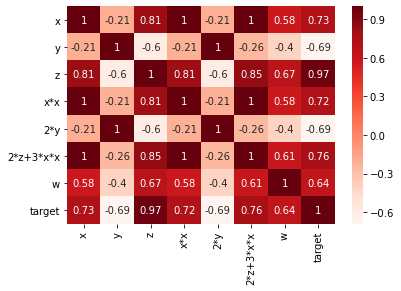

In [99]:
sns.heatmap(data.corr(),annot=True, cmap=plt.cm.Reds)
plt.show()

### Doing perturbation test to check the presence of collinearity  

#### Task: 1 Logistic Regression
<pre>


1. <b>Finding the Correlation between the features</b>
    a. check the correlation between the features
    b. plot heat map of correlation matrix using seaborn heatmap
2. <b>Finding the best model for the given data</b>
    a. Train Logistic regression on data(X,Y) that we have created in the above cell
    b. Find the best hyper prameter alpha with hyper parameter tuning using k-fold cross validation (grid search CV or         
    random search CV make sure you choose the alpha in log space)
    c. Creat a new Logistic regression with the best alpha
    (search for how to get the best hyper parameter value), name the best model as 'best_model'
    
3. <b>Getting the weights with the original data</b>
    a. train the 'best_model' with X, Y
    b. Check the accuracy of the model 'best_model_accuracy'
    c. Get the weights W using best_model.coef_

4. <b>Modifying original data</b>
    a. Add a noise(order of 10^-2) to each element of X 
    and get the new data set X' (X' = X + e)
    b. Train the same 'best_model' with data (X', Y)
    c. Check the accuracy of the model 'best_model_accuracy_edited'
    d. Get the weights W' using best_model.coef_
    
5. <b> Checking deviations in metric and weights </b>
    a. find the difference between 'best_model_accuracy_edited' and 'best_model_accuracy'
    b. find the absolute change between each value of W and W' ==> |(W-W')|
    c. print the top 4 features which have higher % change in weights 
    compare to the other feature

</pre>

#### Task: 2 Linear SVM

<pre>
1. Do the same steps (2, 3, 4, 5) we have done in the above task 1.
</pre>

<strong><font color='red'>Do write the observations based on the results you get from the deviations of weights in both Logistic Regression and linear SVM</font></strong>

# Applying the LR on the original data

In [100]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42)

In [101]:
logistic = LogisticRegression()

In [102]:


C = np.logspace(0,4,10)
#C= [1,3,5,7]

In [103]:
hyperparameters = dict(C=C)

print (hyperparameters)

{'C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04])}


In [104]:
clf = GridSearchCV(logistic, hyperparameters, cv=5, verbose=0)
best_model = clf.fit(X_train, Y_train)
best_model_predict = clf.predict(X_test)

In [105]:
from sklearn.metrics import accuracy_score
print('Best C:', best_model.best_estimator_)

Best C: LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


In [106]:
print('Accuracy Score : ' + str(accuracy_score(Y_test,best_model_predict)))

Accuracy Score : 1.0


In [107]:
params, mean, std = [clf.cv_results_[key] for key in ['params', 'mean_test_score', 'std_test_score']]
c = [p['C'] for p in params]

gridsearch = pd.DataFrame([pd.Series(x) for x in [c, mean]]).T
gridsearch.columns = [ 'C', 'Accuracy: Mean']

gridsearch

,C,Accuracy: Mean
0,1.000000,1.0
1,2.782559,1.0
2,7.742637,1.0
3,21.544347,1.0
4,59.948425,1.0
5,166.810054,1.0
6,464.158883,1.0
7,1291.549665,1.0
8,3593.813664,1.0
9,10000.000000,1.0


# Training the data with the best model 

In [108]:
clf_best_model = LogisticRegression(C=1.0, penalty="l2")

In [109]:
clf_best_model.fit(X_train, Y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [110]:
clf_best_model.score(X_test,Y_test)

1.0

# Getting the coefficient with best data

In [111]:
W  = list(clf_best_model.coef_[0])

In [112]:
W

[0.7128176173835247,
 -0.8382916328034389,
 1.56169403966884,
 0.6564013232431412,
 -0.8382916328034389,
 0.7793139764465893,
 0.502247262049005]

# Modify the data by adding noise 

In [113]:
import numpy as np

In [114]:
 data_noise = data.add(0.001)

In [115]:
data.head()

,x,y,z,x*x,2*y,2*z+3*x*x,w,target
0,-0.581066,0.841837,-1.012978,-0.604025,0.841837,-0.665927,-0.536277,0
1,-0.894309,-0.207835,-1.012978,-0.883052,-0.207835,-0.917054,-0.522364,0
2,-1.207552,0.212034,-1.082312,-1.150918,0.212034,-1.166507,0.205738,0
3,-1.364174,0.002099,-0.943643,-1.280666,0.002099,-1.266540,-0.665720,0
4,-0.737687,1.051772,-1.012978,-0.744934,1.051772,-0.792746,-0.735054,0


In [116]:
data_noise.head()

,x,y,z,x*x,2*y,2*z+3*x*x,w,target
0,-0.580066,0.842837,-1.011978,-0.603025,0.842837,-0.664927,-0.535277,0.001
1,-0.893309,-0.206835,-1.011978,-0.882052,-0.206835,-0.916054,-0.521364,0.001
2,-1.206552,0.213034,-1.081312,-1.149918,0.213034,-1.165507,0.206738,0.001
3,-1.363174,0.003099,-0.942643,-1.279666,0.003099,-1.265540,-0.664720,0.001
4,-0.736687,1.052772,-1.011978,-0.743934,1.052772,-0.791746,-0.734054,0.001


In [117]:
X_noise = data_noise.drop(['target'], axis=1).values

# Train the modified data with the best estimator 

In [118]:
X_noise_train, X_noise_test, Y_train, Y_test = train_test_split(X_noise, Y, random_state=42)

In [119]:
clf_best_model_noise = LogisticRegression(C=1.0, penalty="l2")

In [120]:
clf_best_model_noise.fit(X_noise_train, Y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [121]:
clf_best_model_noise.score(X_noise_test,Y_test)

1.0

# getting the weight of the model on noise data

In [122]:
W_noise = list((clf_best_model_noise.coef_[0]))

In [ ]:
W_noise

# Finding the change in the weight of the model 

In [124]:
abs_value = []
for index,value in enumerate(W):
    abs_val = abs((W[index]-W_noise[index]))
    abs_value.append(abs_val)

In [125]:
abs_value

[5.651412312568382e-07,
 2.0921930521389243e-07,
 1.004190125275528e-06,
 1.1179295692498314e-06,
 2.0921930521389243e-07,
 9.047007133444751e-07,
 9.132894990271367e-07]

In [126]:
percentage_change = []
for index,value in enumerate(abs_value):
    prcntge = (abs_value[index]/W[index])*100
    percentage_change.append(prcntge)

In [127]:
percentage_change

[7.928272498809039e-05,
 -2.4957818619066402e-05,
 6.430133558609653e-05,
 0.0001703119006107995,
 -2.4957818619066402e-05,
 0.0001160893735628363,
 0.00018184061278924915]

In [128]:
feature_list = list(data.columns)

In [129]:
feature_list

['x', 'y', 'z', 'x*x', '2*y', '2*z+3*x*x', 'w', 'target']

In [130]:
feature_change_detail = {}
for index ,value in enumerate(percentage_change) :
    feature_change_detail.update({feature_list[index]:value})

In [131]:
feature_change_detail

{'x': 7.928272498809039e-05,
 'y': -2.4957818619066402e-05,
 'z': 6.430133558609653e-05,
 'x*x': 0.0001703119006107995,
 '2*y': -2.4957818619066402e-05,
 '2*z+3*x*x': 0.0001160893735628363,
 'w': 0.00018184061278924915}

In [132]:
import operator
sorted_feature_change_detail = dict(sorted(feature_change_detail.items(), key=operator.itemgetter(1),reverse=True))

In [133]:
sorted_feature_change_detail

{'w': 0.00018184061278924915,
 'x*x': 0.0001703119006107995,
 '2*z+3*x*x': 0.0001160893735628363,
 'x': 7.928272498809039e-05,
 'z': 6.430133558609653e-05,
 'y': -2.4957818619066402e-05,
 '2*y': -2.4957818619066402e-05}

# The top 4 features which have higher % change in weights compare to the other feature

In [134]:
from itertools import islice

def take(n, iterable):
    "Return first n items of the iterable as a list"
    return list(islice(iterable, n))


In [135]:
n_items = take(4, sorted_feature_change_detail.items())

In [136]:
n_items

[('w', 0.00018184061278924915),
 ('x*x', 0.0001703119006107995),
 ('2*z+3*x*x', 0.0001160893735628363),
 ('x', 7.928272498809039e-05)]

# Applying Linear SVM on the original data

In [137]:
from sklearn.svm import SVC

In [138]:
linear_svm = SVC(kernel='linear',decision_function_shape="ovr",random_state=0)

In [139]:
C = np.logspace(0,4,10)

In [140]:
hyperparameters = dict(C=C)

print (hyperparameters)

{'C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04])}


In [141]:
clf_svm = GridSearchCV(linear_svm, hyperparameters, cv=5, verbose=0)
best_model_svm = clf_svm.fit(X_train, Y_train)
best_model_predict_svm = clf_svm.predict(X_test)

In [142]:
print('Best C:', best_model_svm.best_estimator_)

Best C: SVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='linear',
    max_iter=-1, probability=False, random_state=0, shrinking=True, tol=0.001,
    verbose=False)


In [143]:
print('Accuracy Score : ' + str(accuracy_score(Y_test,best_model_predict_svm)))

Accuracy Score : 1.0


# Training the orignal data with the best hyper-parameter

In [144]:
clf_best_model_svm = SVC(C=1.0,kernel='linear',decision_function_shape="ovr",random_state=0)

In [145]:
clf_best_model_svm.fit(X_train, Y_train)

SVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='linear',
    max_iter=-1, probability=False, random_state=0, shrinking=True, tol=0.001,
    verbose=False)

In [146]:
clf_best_model_svm.score(X_test,Y_test)

1.0

In [147]:
W_svm  = list(clf_best_model_svm.coef_[0]) 

In [148]:
print(W_svm)

[0.4033854842023213, -0.28031444716098547, 1.0032212375640035, 0.33082479768478557, -0.28031444716098547, 0.4188664568353745, 0.3015646026423849]


# Train the noise data with best hyper parameter value

In [149]:
clf_best_model_noise_svm = SVC(C=1.0,kernel='linear',decision_function_shape="ovr",random_state=0)

In [150]:
clf_best_model_noise_svm.fit(X_noise_train, Y_train)

SVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='linear',
    max_iter=-1, probability=False, random_state=0, shrinking=True, tol=0.001,
    verbose=False)

In [151]:
clf_best_model_noise_svm.score(X_noise_test,Y_test)

1.0

In [152]:
W_noise_svm = list(clf_best_model_noise_svm.coef_[0])

# Getting the weights on noise data

In [153]:
print(W_noise_svm)

[0.4033854204216169, -0.28031445705101565, 1.00322113747448, 0.3308247437141353, -0.28031445705101565, 0.4188663961772643, 0.3015645828461546]


# Finding the change in the weight 

In [154]:
abs_value_svm = []
for index,value in enumerate(W_svm):
    abs_val = abs((W_svm[index]-W_noise_svm[index]))
    abs_value_svm.append(abs_val)
print(abs_value_svm)    

[6.378070438461947e-08, 9.89003018370127e-09, 1.0008952355811118e-07, 5.397065028223125e-08, 9.89003018370127e-09, 6.065811020139478e-08, 1.9796230266155845e-08]


In [155]:
percentage_change_svm = []
for index,value in enumerate(abs_value_svm):
    prcntge = (abs_value_svm[index]/W_svm[index])*100
    percentage_change_svm.append(prcntge)
print(percentage_change_svm)    

[1.5811353378454674e-05, -3.5281913878742737e-06, 9.976814665641054e-06, 1.631396759249445e-05, -3.5281913878742737e-06, 1.4481491466201363e-05, 6.564507270646587e-06]


In [156]:
feature_change_detail_svm = {}
for index ,value in enumerate(percentage_change_svm) :
    feature_change_detail_svm.update({feature_list[index]:value})
print(feature_change_detail_svm)    

{'x': 1.5811353378454674e-05, 'y': -3.5281913878742737e-06, 'z': 9.976814665641054e-06, 'x*x': 1.631396759249445e-05, '2*y': -3.5281913878742737e-06, '2*z+3*x*x': 1.4481491466201363e-05, 'w': 6.564507270646587e-06}


In [157]:
sorted_feature_change_detail_svm = dict(sorted(feature_change_detail_svm.items(), key=operator.itemgetter(1),reverse=True))

print(sorted_feature_change_detail_svm)

{'x*x': 1.631396759249445e-05, 'x': 1.5811353378454674e-05, '2*z+3*x*x': 1.4481491466201363e-05, 'z': 9.976814665641054e-06, 'w': 6.564507270646587e-06, 'y': -3.5281913878742737e-06, '2*y': -3.5281913878742737e-06}


# The top 4 features which have higher % change in weights compare to the other feature

In [158]:
def take(n, iterable):
    "Return first n items of the iterable as a list"
    return list(islice(iterable, n))
n_items_svm = take(4, sorted_feature_change_detail_svm.items())

In [159]:
print(n_items_svm)

[('x*x', 1.631396759249445e-05), ('x', 1.5811353378454674e-05), ('2*z+3*x*x', 1.4481491466201363e-05), ('z', 9.976814665641054e-06)]


# Observation 

By applying LR on the original data and the modified data the 
top 4 features which have higher % change in weights compare to the other feature are
{'w', 0.00018184061278924915 %},
{'x*x', 0.0001703119006107995 %},
{'2*z+3*x*x', 0.0001160893735628363 %},
{'x' 7.928272498809039e-05 %}


By applying LR on the original data and the modified data the 
top 4 features which have higher % change in weights compare to the other feature are

{'x*x', 1.631396759249445e-05 %}, 
{'x', 1.5811353378454674e-05%},
{'2*z+3*x*x' 1.4481491466201363e-05%}, 
{'z' 9.976814665641054e-06%}
 